In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from src.utils.fullSteinerSolverHyperbolic import isopticCurve, hyperbolicInnerAngleTriangle
from src.utils.steinerUtils import steinerPoint3
from src.utils.fullSteinerSolverEuclidean import equilateral_triangle
import matplotlib.lines as mlines
from pathlib import Path
import matplotlib.patches as patches


try:
    from phcpy.phcpy2c3 import py2c_set_seed
    ALLOW_PRECISE = True
    
except ModuleNotFoundError:
    ALLOW_PRECISE = False
    

def seed_all(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    if ALLOW_PRECISE:
        py2c_set_seed(seed)

seed_all(42)

FIG_PATH =  Path("./Figures/Results")
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

Is the phcpy2c3.so not suited for this platform?


In [3]:
def circumradius(x, y, Ux, Uy):
    """
    Calculate the circumradius given the circumcenter and a vertex.
    """
    return np.sqrt((x - Ux)**2 + (y - Uy)**2)

def circumcenter(x1, y1, x2, y2, x3, y3):
    """
    Calculate the circumcenter of a triangle given its three vertices.
    """
    D = 2 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
    Ux = ((x1**2 + y1**2) * (y2 - y3) + (x2**2 + y2**2) * (y3 - y1) + (x3**2 + y3**2) * (y1 - y2)) / D
    Uy = ((x1**2 + y1**2) * (x3 - x2) + (x2**2 + y2**2) * (x1 - x3) + (x3**2 + y3**2) * (x2 - x1)) / D
    return Ux, Uy

def draw_circumcircle(ax, p1, p2, p3, c="tab:red", linewidth=3, linestyle=(5, (10, 8))):
    """
    Draw the circumcircle and its arc given three vertices of a triangle.
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    
    Ux, Uy = circumcenter(x1, y1, x2, y2, x3, y3)
    r = circumradius(x1, y1, Ux, Uy)

    # Plot the full circumcircle
    circumcircle = plt.Circle(
        (Ux, Uy), r, fill=False, color=c,
        linestyle=linestyle, linewidth=linewidth, alpha=0.8
    )
    ax.add_artist(circumcircle)

    # Compute arc angles
    theta1 = np.arctan2(y1 - Uy, x1 - Ux)
    theta2 = np.arctan2(y2 - Uy, x2 - Ux)
    if theta2 < theta1:
        theta2 += 2 * np.pi

    # Check if arc should flip (to include p3 or exclude it)
    p = (Ux + r*np.cos((theta1 + theta2) / 2), Uy + r*np.sin((theta1 + theta2) / 2))
    if np.all(np.isclose(p, [x3, y3])):
        theta1, theta2 = theta2, theta1

    # Convert to degrees for patches.Arc
    theta1 = np.degrees(theta1)
    theta2 = np.degrees(theta2)

    # Plot the arc
    arc = patches.Arc(
        (Ux, Uy), 2 * r, 2 * r,
        theta1=theta1, theta2=theta2,
        color=c, linewidth=linewidth
    )
    ax.add_patch(arc)


In [4]:
def polyIso(p, q, s, model="Klein"):
    a, b = p
    c, d = q
    x, y = s
    
    if model=="Klein":
        eq = 3*a**2*c**2*y**4 - 6*a**2*c**2*y**2 + 3*a**2*c**2 - 6*a**2*c*d*x*y**3 +\
                6*a**2*c*d*x*y + 6*a**2*c*x*y**2 - 6*a**2*c*x + 3*a**2*d**2*x**2*y**2 +\
                a**2*d**2*x**2 + a**2*d**2*y**2 - a**2*d**2 - 8*a**2*d*x**2*y -\
                2*a**2*d*y**3 + 2*a**2*d*y + a**2*x**2*y**2 + 3*a**2*x**2 +\
                a**2*y**4 - a**2*y**2 - 6*a*b*c**2*x*y**3 + 6*a*b*c**2*x*y +\
                12*a*b*c*d*x**2*y**2 - 8*a*b*c*d*x**2 - 8*a*b*c*d*y**2 + 8*a*b*c*d -\
                4*a*b*c*x**2*y + 8*a*b*c*y**3 - 8*a*b*c*y - 6*a*b*d**2*x**3*y +\
                6*a*b*d**2*x*y + 8*a*b*d*x**3 - 4*a*b*d*x*y**2 - 8*a*b*d*x - 2*a*b*x**3*y -\
                2*a*b*x*y**3 + 8*a*b*x*y + 6*a*c**2*x*y**2 - 6*a*c**2*x - 4*a*c*d*x**2*y +\
                8*a*c*d*y**3 - 8*a*c*d*y - 8*a*c*x**2*y**2 + 12*a*c*x**2 - 8*a*c*y**4 +\
                8*a*c*y**2 - 2*a*d**2*x**3 - 8*a*d**2*x*y**2 + 2*a*d**2*x + 8*a*d*x**3*y +\
                8*a*d*x*y**3 + 4*a*d*x*y - 6*a*x**3 - 6*a*x*y**2 + 3*b**2*c**2*x**2*y**2 +\
                b**2*c**2*x**2 + b**2*c**2*y**2 - b**2*c**2 - 6*b**2*c*d*x**3*y +\
                6*b**2*c*d*x*y - 2*b**2*c*x**3 - 8*b**2*c*x*y**2 + 2*b**2*c*x +\
                3*b**2*d**2*x**4 - 6*b**2*d**2*x**2 + 3*b**2*d**2 + 6*b**2*d*x**2*y -\
                6*b**2*d*y + b**2*x**4 + b**2*x**2*y**2 - b**2*x**2 + 3*b**2*y**2 -\
                8*b*c**2*x**2*y - 2*b*c**2*y**3 + 2*b*c**2*y + 8*b*c*d*x**3 -\
                4*b*c*d*x*y**2 - 8*b*c*d*x + 8*b*c*x**3*y + 8*b*c*x*y**3 + 4*b*c*x*y +\
                6*b*d**2*x**2*y - 6*b*d**2*y - 8*b*d*x**4 - 8*b*d*x**2*y**2 +\
                8*b*d*x**2 + 12*b*d*y**2 - 6*b*x**2*y - 6*b*y**3 + c**2*x**2*y**2 +\
                3*c**2*x**2 + c**2*y**4 - c**2*y**2 - 2*c*d*x**3*y - 2*c*d*x*y**3 +\
                8*c*d*x*y - 6*c*x**3 - 6*c*x*y**2 + d**2*x**4 + d**2*x**2*y**2 -\
                d**2*x**2 + 3*d**2*y**2 - 6*d*x**2*y - 6*d*y**3 + 3*x**4 + 6*x**2*y**2 + 3*y**4
    
    elif model == "Half":
        eq = 3*a**4*c**4 - 12*a**4*c**3*x + 6*a**4*c**2*d**2 + 18*a**4*c**2*x**2 -\
                10*a**4*c**2*y**2 - 12*a**4*c*d**2*x - 12*a**4*c*x**3 + 20*a**4*c*x*y**2 +\
                3*a**4*d**4 + 6*a**4*d**2*x**2 - 6*a**4*d**2*y**2 + 3*a**4*x**4 - 10*a**4*x**2*y**2 +\
                3*a**4*y**4 - 12*a**3*c**4*x + 48*a**3*c**3*x**2 + 32*a**3*c**3*y**2 -\
                24*a**3*c**2*d**2*x - 72*a**3*c**2*x**3 - 56*a**3*c**2*x*y**2 + 48*a**3*c*d**2*x**2 +\
                32*a**3*c*d**2*y**2 + 48*a**3*c*x**4 + 16*a**3*c*x**2*y**2 - 32*a**3*c*y**4 -\
                12*a**3*d**4*x - 24*a**3*d**2*x**3 - 8*a**3*d**2*x*y**2 - 12*a**3*x**5 +\
                8*a**3*x**3*y**2 + 20*a**3*x*y**4 + 6*a**2*b**2*c**4 - 24*a**2*b**2*c**3*x +\
                12*a**2*b**2*c**2*d**2 + 36*a**2*b**2*c**2*x**2 - 20*a**2*b**2*c**2*y**2 -\
                24*a**2*b**2*c*d**2*x - 24*a**2*b**2*c*x**3 + 40*a**2*b**2*c*x*y**2 +\
                6*a**2*b**2*d**4 + 12*a**2*b**2*d**2*x**2 - 12*a**2*b**2*d**2*y**2 + 6*a**2*b**2*x**4 -\
                20*a**2*b**2*x**2*y**2 + 6*a**2*b**2*y**4 + 18*a**2*c**4*x**2 - 10*a**2*c**4*y**2 -\
                72*a**2*c**3*x**3 - 56*a**2*c**3*x*y**2 + 36*a**2*c**2*d**2*x**2 -\
                20*a**2*c**2*d**2*y**2 + 108*a**2*c**2*x**4 + 168*a**2*c**2*x**2*y**2 +\
                76*a**2*c**2*y**4 - 72*a**2*c*d**2*x**3 - 56*a**2*c*d**2*x*y**2 -\
                72*a**2*c*x**5 - 128*a**2*c*x**3*y**2 - 56*a**2*c*x*y**4 + 18*a**2*d**4*x**2 -\
                10*a**2*d**4*y**2 + 36*a**2*d**2*x**4 + 40*a**2*d**2*x**2*y**2 +\
                20*a**2*d**2*y**4 + 18*a**2*x**6 + 26*a**2*x**4*y**2 - 2*a**2*x**2*y**4 -\
                10*a**2*y**6 - 12*a*b**2*c**4*x + 48*a*b**2*c**3*x**2 + 32*a*b**2*c**3*y**2 -\
                24*a*b**2*c**2*d**2*x - 72*a*b**2*c**2*x**3 - 56*a*b**2*c**2*x*y**2 +\
                48*a*b**2*c*d**2*x**2 + 32*a*b**2*c*d**2*y**2 + 48*a*b**2*c*x**4 +\
                16*a*b**2*c*x**2*y**2 - 32*a*b**2*c*y**4 - 12*a*b**2*d**4*x - 24*a*b**2*d**2*x**3 -\
                8*a*b**2*d**2*x*y**2 - 12*a*b**2*x**5 + 8*a*b**2*x**3*y**2 + 20*a*b**2*x*y**4 -\
                12*a*c**4*x**3 + 20*a*c**4*x*y**2 + 48*a*c**3*x**4 + 16*a*c**3*x**2*y**2 -\
                32*a*c**3*y**4 - 24*a*c**2*d**2*x**3 + 40*a*c**2*d**2*x*y**2 - 72*a*c**2*x**5 -\
                128*a*c**2*x**3*y**2 - 56*a*c**2*x*y**4 + 48*a*c*d**2*x**4 + 16*a*c*d**2*x**2*y**2 -\
                32*a*c*d**2*y**4 + 48*a*c*x**6 + 128*a*c*x**4*y**2 + 112*a*c*x**2*y**4 + 32*a*c*y**6 -\
                12*a*d**4*x**3 + 20*a*d**4*x*y**2 - 24*a*d**2*x**5 - 32*a*d**2*x**3*y**2 - 8*a*d**2*x*y**4 -\
                12*a*x**7 - 36*a*x**5*y**2 - 36*a*x**3*y**4 - 12*a*x*y**6 + 3*b**4*c**4 -\
                12*b**4*c**3*x + 6*b**4*c**2*d**2 + 18*b**4*c**2*x**2 - 10*b**4*c**2*y**2 -\
                12*b**4*c*d**2*x - 12*b**4*c*x**3 + 20*b**4*c*x*y**2 + 3*b**4*d**4 + 6*b**4*d**2*x**2 -\
                6*b**4*d**2*y**2 + 3*b**4*x**4 - 10*b**4*x**2*y**2 + 3*b**4*y**4 + 6*b**2*c**4*x**2 -\
                6*b**2*c**4*y**2 - 24*b**2*c**3*x**3 - 8*b**2*c**3*x*y**2 + 12*b**2*c**2*d**2*x**2 -\
                12*b**2*c**2*d**2*y**2 + 36*b**2*c**2*x**4 + 40*b**2*c**2*x**2*y**2 + 20*b**2*c**2*y**4 -\
                24*b**2*c*d**2*x**3 - 8*b**2*c*d**2*x*y**2 - 24*b**2*c*x**5 - 32*b**2*c*x**3*y**2 -\
                8*b**2*c*x*y**4 + 6*b**2*d**4*x**2 - 6*b**2*d**4*y**2 + 12*b**2*d**2*x**4 +\
                8*b**2*d**2*x**2*y**2 + 12*b**2*d**2*y**4 + 6*b**2*x**6 + 6*b**2*x**4*y**2 -\
                6*b**2*x**2*y**4 - 6*b**2*y**6 + 3*c**4*x**4 - 10*c**4*x**2*y**2 + 3*c**4*y**4 -\
                12*c**3*x**5 + 8*c**3*x**3*y**2 + 20*c**3*x*y**4 + 6*c**2*d**2*x**4 -\
                20*c**2*d**2*x**2*y**2 + 6*c**2*d**2*y**4 + 18*c**2*x**6 + 26*c**2*x**4*y**2 -\
                2*c**2*x**2*y**4 - 10*c**2*y**6 - 12*c*d**2*x**5 + 8*c*d**2*x**3*y**2 + 20*c*d**2*x*y**4 -\
                12*c*x**7 - 36*c*x**5*y**2 - 36*c*x**3*y**4 - 12*c*x*y**6 + 3*d**4*x**4 -\
                10*d**4*x**2*y**2 + 3*d**4*y**4 + 6*d**2*x**6 + 6*d**2*x**4*y**2 - 6*d**2*x**2*y**4 -\
                6*d**2*y**6 + 3*x**8 + 12*x**6*y**2 + 18*x**4*y**4 + 12*x**2*y**6 + 3*y**8

    else:
        raise ValueError("model should be either 'Klein' or 'Half'")
    
    return eq

In [5]:
# --- Main function ---
def drawIsoptic(p1, p2, p3, poly=False, space="Klein", dist2Points=1e-5, precise=True, borders=None):
    """
    Draws isoptic curves/triangles in different geometries (Klein, Half-plane, Euclidean).
    """

    precise = precise and ALLOW_PRECISE

    point = steinerPoint3([p1, p2, p3], model=space,
                          dist2Points=dist2Points, precise=precise)
    print(point)

    # --- Style constants (Klein baseline) ---
    LINEWIDTH = 3
    CIRCLE_LINEWIDTH = 4
    STEINER_SIZE = 650
    TERMINAL_SIZE = 180
    MARKER_EDGEWIDTH = 1

    fig = plt.figure(figsize=(5, 5), dpi=200)
    ax = fig.add_subplot(111, aspect='equal')

    # --- Klein & Half-plane models ---
    if space in ["Klein", "Half"]:
        if space == "Klein":
            X, Y = np.meshgrid(np.linspace(-1.15, 1.15, 500),
                               np.linspace(-1.15, 1.15, 500))
        else:  # Half-plane
            if borders is None:
                borders = [1 if not poly else 5] * 2
            minX = min([p1[0], p2[0], p3[0]]) - borders[0]
            maxX = max([p1[0], p2[0], p3[0]]) + borders[0]
            maxY = max([p1[1], p2[1], p3[1]]) + borders[1]
            X, Y = np.meshgrid(np.linspace(minX, maxX, 1000),
                               np.linspace(-maxY, maxY, 1000))

        if poly:
            ax.contour(X, Y, polyIso(p1, p2, [X, Y], model=space), 0,
                       colors="#768D21", zorder=1,
                       linestyles="dashed", linewidths=LINEWIDTH)
            ax.contour(X, Y, polyIso(p2, p3, [X, Y], model=space), 0,
                       colors="#C03E35", zorder=1,
                       linestyles="dashed", linewidths=LINEWIDTH)
        else:
            ax.contour(X, Y, isopticCurve(p1, p3, [X, Y], model=space), 0,
                       colors="#205EA6", zorder=1, linewidths=LINEWIDTH)

        ax.contour(X, Y, isopticCurve(p1, p2, [X, Y], model=space), 0,
                   colors="#768D21", zorder=2, linewidths=LINEWIDTH)
        ax.contour(X, Y, isopticCurve(p2, p3, [X, Y], model=space), 0,
                   colors="#C03E35", zorder=2, linewidths=LINEWIDTH)

        if space == "Klein":
            circ = plt.Circle((0, 0), radius=1, edgecolor='black',
                              facecolor='None', linewidth=CIRCLE_LINEWIDTH, alpha=0.5)
            ax.add_patch(circ)
        else:  # Half-plane
            ax.axhspan(0, maxY, facecolor='lavender', alpha=0.5, zorder=0)

    # --- Euclidean model ---
    elif space == "Euclidean":
        colors = ["#768D21", "#C03E35", "#205EA6"]
        vertices = [p1, p2, p3]

        # Collect points for bounding box
        all_points = [p1, p2, p3]

        for i, c in enumerate(colors):
            v1 = vertices[i]
            v2 = vertices[(i + 1) % 3]
            v3 = vertices[(i + 2) % 3]
            equilateral_point = equilateral_triangle(v1, v2, v3)
            all_points.append(equilateral_point)

            # Triangle fill
            triangle = plt.Polygon([v1, v2, equilateral_point],
                                   fill=True, color='#B7B5AC', alpha=0.3)
            ax.add_artist(triangle)

            # Circumcircle
            draw_circumcircle(ax, v1, v2, equilateral_point, c=c, linewidth=3)

            # Add circumcircle extremes to bounding box
            Ux, Uy = circumcenter(*v1, *v2, *equilateral_point)
            r = circumradius(v1[0], v1[1], Ux, Uy)
            all_points.extend([
                (Ux - r, Uy), (Ux + r, Uy),
                (Ux, Uy - r), (Ux, Uy + r)
            ])

        # Bounding box (tight fit)
        all_x = [pt[0] for pt in all_points]
        all_y = [pt[1] for pt in all_points]
        dx = max(all_x) - min(all_x)
        dy = max(all_y) - min(all_y)
        margin = 0.05
        ax.set_xlim(min(all_x) - margin * dx, max(all_x) + margin * dx)
        ax.set_ylim(min(all_y) - margin * dy, max(all_y) + margin * dy)

        # --- Reduce marker and line sizes for visual match ---
        # LINEWIDTH = 5
        # CIRCLE_LINEWIDTH = 5
        # STEINER_SIZE = 600
        # TERMINAL_SIZE = 200

    # --- Scatter Steiner point & terminals ---
    if point is not None:
        ax.scatter(point[0], point[1], marker="*", c="#282726",
                   s=STEINER_SIZE, edgecolors="#F7F7F5",
                   linewidths=MARKER_EDGEWIDTH, zorder=10)

    for p in [p1, p2, p3]:
        ax.scatter(p[0], p[1], marker="s", c="#282726",
                   s=TERMINAL_SIZE, edgecolors="#F7F7F5",
                   linewidths=MARKER_EDGEWIDTH, zorder=10)

    # --- Axis styling ---
    if space == "Half":
        ax.spines['bottom'].set_position('center')
        ax.spines['left'].set_color('none')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.set_yticks([])
        ax.set_xticks([])
    else:
        ax.axis('off')

    fig.tight_layout()

    filename = f"isoptics_{space}" if not poly else f"polySys_{space}"
    fig.savefig(FIG_PATH / f"{filename}.pdf")

    plt.show()

    return point

In [ ]:
p1 = np.array([-3, 1])
p2 = np.array([2, 1])
p3 = np.array([1,5])

drawIsoptic(p1, p2, p3, poly=False, space="Half", dist2Points=1e-5, precise=False, borders=[1, 1]);

In [ ]:
p1 = np.array([-0.70, 0.02705193])
p2 = np.array([-0.09223223, 0.66927742])
p3 = np.array([0.7170893,-0.29871065])

drawIsoptic(p1, p2, p3, poly=False, space="Euclidean", dist2Points=1e-5);

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


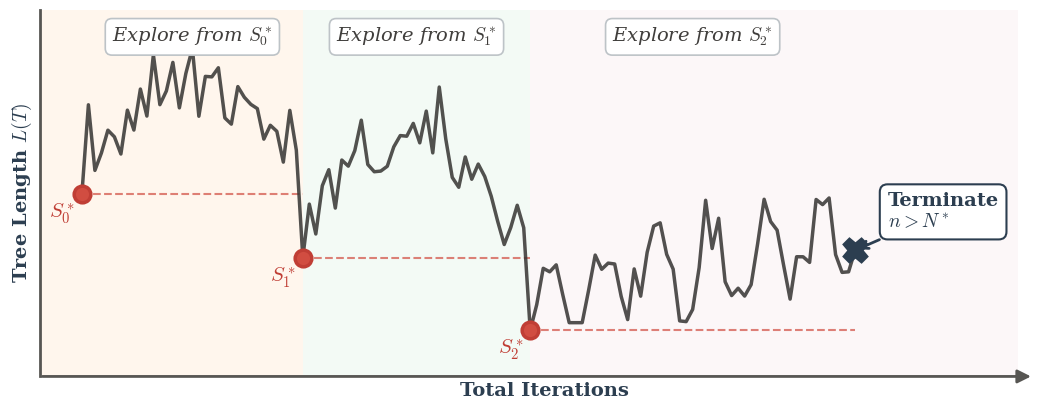

Figure saved as 'exploration_policy.pdf' and 'exploration_policy.png'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, FancyArrowPatch

# ============= CONFIGURATION =============
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = False


# Set up matplotlib for NeurIPS style
plt.rcParams.update(
    {
        # Use serif fonts - NeurIPS uses Times Roman (ptm)
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        # Font sizes
        "font.size": 20,  # Regular text
        "axes.titlesize": 14,  # Title size
        "axes.labelsize": 18,  # Axis label size
        "xtick.labelsize": 18,  # X tick label size
        "ytick.labelsize": 18,  # Y tick label size
        "legend.fontsize": 16,  # Legend font size
        # Line widths
        "axes.linewidth": 0.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 1.0,
        "lines.markersize": 3,
        # Clean style for academic publications
        "axes.grid": False,
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "#CCCCCC",
        "grid.linestyle": "--",
        # Legend settings
        "legend.frameon": False,
        "legend.numpoints": 1,
        "legend.handlelength": 2,
        # Use TrueType fonts for better PDF output
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# Colors
PHASE_COLORS = ['#FFE7CE', '#DDF1E4', '#F8EAEC']
PATH_COLOR = '#343331'
CHECKPOINT_COLOR = '#D14D41'
CHECKPOINT_EDGE_COLOR = '#C03E35'
TERMINATION_COLOR = '#2C3E50'

# ============= GENERATE PATH DATA =============
def generate_exploration_phase(x_start, current_best, n_steps, improvement_amount=0.08):
    """Generate exploration phase with potential improvement"""
    x_path, y_path = [], []
    x = x_start
    
    for i in range(n_steps):
        x += 0.02
        progress = i / n_steps
        
        # Oscillations above current best
        oscillation = 0.1 * np.sin(8 * np.pi * progress) + 0.03 * np.random.randn()
        
        # Sharp descent near end for breakthrough
        descent = -0.30 * ((progress - 0.8) / 0.2) ** 3 if progress > 0.8 else 0
        
        y = current_best + 0.05 + oscillation + descent
        
        # Check for improvement
        if y < current_best:
            y -= improvement_amount  # Enlarge visual difference
            x_path.append(x)
            y_path.append(y)
            return x_path, y_path, x, y, True
        
        x_path.append(x)
        y_path.append(y)
    
    return x_path, y_path, x, None, False

# Initialize data structures
x_path, y_path = [0], [0.75]
checkpoints = [(0, 0.75)]
current_best = 0.75
x = 0

# Phase 1: Explore from S0 to S1
phase1_x, phase1_y, x, new_best, found = generate_exploration_phase(x, current_best, 250)
x_path.extend(phase1_x)
y_path.extend(phase1_y)
if found:
    checkpoints.append((x, new_best))
    current_best = new_best

# Phase 2: Explore from S1 to S2
phase2_x, phase2_y, x, new_best, found = generate_exploration_phase(x, current_best, 250)
x_path.extend(phase2_x)
y_path.extend(phase2_y)
if found:
    checkpoints.append((x, new_best))
    current_best = new_best

# Phase 3: Final exploration (no improvement)
for i in range(50):
    x += 0.02
    progress = i / 50
    oscillation = 0.06 * np.sin(12 * np.pi * progress) + 0.02 * np.random.randn()
    upward_drift = 0.1 * progress
    y = max(current_best + 0.03 + oscillation + upward_drift, current_best + 0.01)
    x_path.append(x)
    y_path.append(y)

# ============= CREATE FIGURE =============
fig, ax = plt.subplots(figsize=(11, 4.5))

# Calculate tight bounds
y_min = min(y_path) - 0.06
y_max = max(y_path) + 0.05

# ============= PLOT ELEMENTS =============

# 1. Shaded exploration phases
phase_starts = [ck[0] for ck in checkpoints] + [x_path[-1]]

# Extended phase boundaries
phase_boundaries = [
    (phase_starts[0] - 0.15, phase_starts[1]),  # Blue phase - extend left
    (phase_starts[1], phase_starts[2]),          # Green phase - no change
    (phase_starts[2], x_path[-1] + 0.5)         # Yellow phase - extend right
]

for idx in range(len(checkpoints)):
    x_start, x_end = phase_boundaries[idx]
    rect = Rectangle((x_start, y_min), x_end - x_start, y_max - y_min, 
                     facecolor=PHASE_COLORS[idx % 3], alpha=0.35, zorder=0)
    ax.add_patch(rect)

# 2. Main path
ax.plot(x_path, y_path, color=PATH_COLOR, linewidth=2.5, alpha=0.85, zorder=3)

# 3. Checkpoints and reference lines
for i, (x_ck, y_ck) in enumerate(checkpoints):
    # Checkpoint marker
    ax.plot(x_ck, y_ck, 'o', color=CHECKPOINT_COLOR, markersize=12, zorder=5, 
           markeredgecolor=CHECKPOINT_EDGE_COLOR, markeredgewidth=2.5)
    
    # Checkpoint label
    ax.text(x_ck-0.06, y_ck - 0.01, f'$S_{i}^*$', fontsize=15, ha='center', 
           va='top', weight='bold', color=CHECKPOINT_EDGE_COLOR)
    
    # Horizontal reference line
    x_next = phase_starts[i + 1]
    ax.hlines(y_ck, x_ck, x_next, colors=CHECKPOINT_COLOR, linestyles='--', 
             linewidth=1.5, alpha=0.7, zorder=2)

# 4. Phase labels
for idx in range(len(checkpoints)):
    mid_x = (phase_starts[idx] + phase_starts[idx + 1]) / 2
    ax.text(mid_x, y_max - 0.02, f'Explore from $S_{idx}^*$', 
           fontsize=14, ha='center', va='top', style='italic', color='#403E3C',
           bbox=dict(boxstyle='round,pad=0.35', facecolor='white', 
                    alpha=1, edgecolor='#BDC3C7', linewidth=1.2))

# 5. Termination marker
ax.plot(x_path[-1], y_path[-1], 'X', color=TERMINATION_COLOR, 
       markersize=16, markeredgewidth=2.5, zorder=5)
ax.annotate('Terminate\n$n > N^*$', xy=(x_path[-1], y_path[-1]),
           xytext=(x_path[-1] + 0.1, y_path[-1]+ 0.05), fontsize=14, 
           va='center', ha='left', weight='bold', color=TERMINATION_COLOR,
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                    alpha=1, edgecolor=TERMINATION_COLOR, linewidth=1.5),
           arrowprops=dict(arrowstyle='->', lw=2, color=TERMINATION_COLOR))



# ============= STYLING =============
ax.set_xlabel('Total Iterations', fontsize=14, weight='bold', color=TERMINATION_COLOR)
ax.set_ylabel('Tree Length $L(T)$', fontsize=14, weight='bold', color=TERMINATION_COLOR)
ax.set_xlim(phase_starts[0] - 0.13, x_path[-1] + 0.5)
ax.set_ylim(y_min, y_max)
ax.set_xticks([])
ax.set_yticks([])

# Clean spines
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
for spine in ['left']:
    ax.spines[spine].set_linewidth(2)
    ax.spines[spine].set_color('#575653')

# Add x-axis arrow with padding so head isn't cropped
x_start, x_end = ax.get_xlim()
arrow = FancyArrowPatch(
    (x_start, y_min), 
    (x_end + 0.05, y_min),  # extend a bit beyond axis
    arrowstyle='-|>',
    mutation_scale=20,
    linewidth=2,
    color='#575653',
    clip_on=False   # prevents cropping at the boundary
)
ax.add_patch(arrow)

# Add a little extra space so arrowhead is visible
ax.set_xlim(x_start, x_end + 0.1)


# Title
# fig.suptitle('Restart Policy: Continue exploring until $\\ell(T) < \\ell(T^*)$, then restart from new checkpoint', 
#             fontsize=12, y=0.99, style='italic', color=TERMINATION_COLOR)

# ============= SAVE AND DISPLAY =============
plt.tight_layout()
plt.savefig(FIG_PATH /'exploration_policy.pdf', dpi=300, bbox_inches='tight')
plt.savefig(FIG_PATH /'exploration_policy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'exploration_policy.pdf' and 'exploration_policy.png'")

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


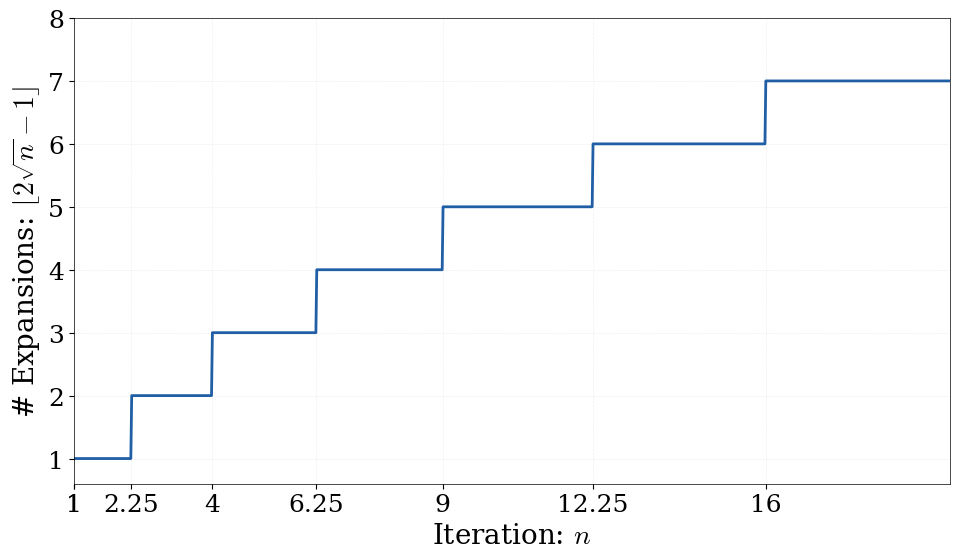

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(n):
    return np.floor(2 * np.sqrt(n) - 1)

# Create x values
n = np.linspace(1, 20, 1000)

# Calculate y values
y = f(n)

# Find where the step function changes
# The function changes when 2*sqrt(n) - 1 crosses an integer
# This happens at n = ((k+1)/2)^2 for integer k
step_changes = []
k = 1
while True:
    n_change = ((k + 1) / 2) ** 2
    if n_change > 20:
        break
    step_changes.append(n_change)
    k += 1

# Add the starting point
step_changes = [1] + step_changes

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Plot the function
ax.plot(n, y, linewidth=2, color='#205EA6', label=r'$\lfloor 2\sqrt{n} - 1 \rfloor$')

# Add grid
ax.grid(True, alpha=0.3)

# Labels and title
ax.set_xlabel(r'Iteration: $n$', fontsize=20)
ax.set_ylabel(r'# Expansions: $\lfloor 2\sqrt{n} - 1 \rfloor$', fontsize=20)

# Set x-ticks at step changes
ax.set_xticks(step_changes)
ax.set_xticklabels([f'{x:.2f}' if x != int(x) else f'{int(x)}' for x in step_changes])

# Set axis limits
ax.set_xlim(1, 20)
ax.set_ylim(0.6, max(y) + 1)

plt.tight_layout()
plt.savefig(FIG_PATH / 'expansion_curve.pdf', dpi=300, bbox_inches='tight')

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


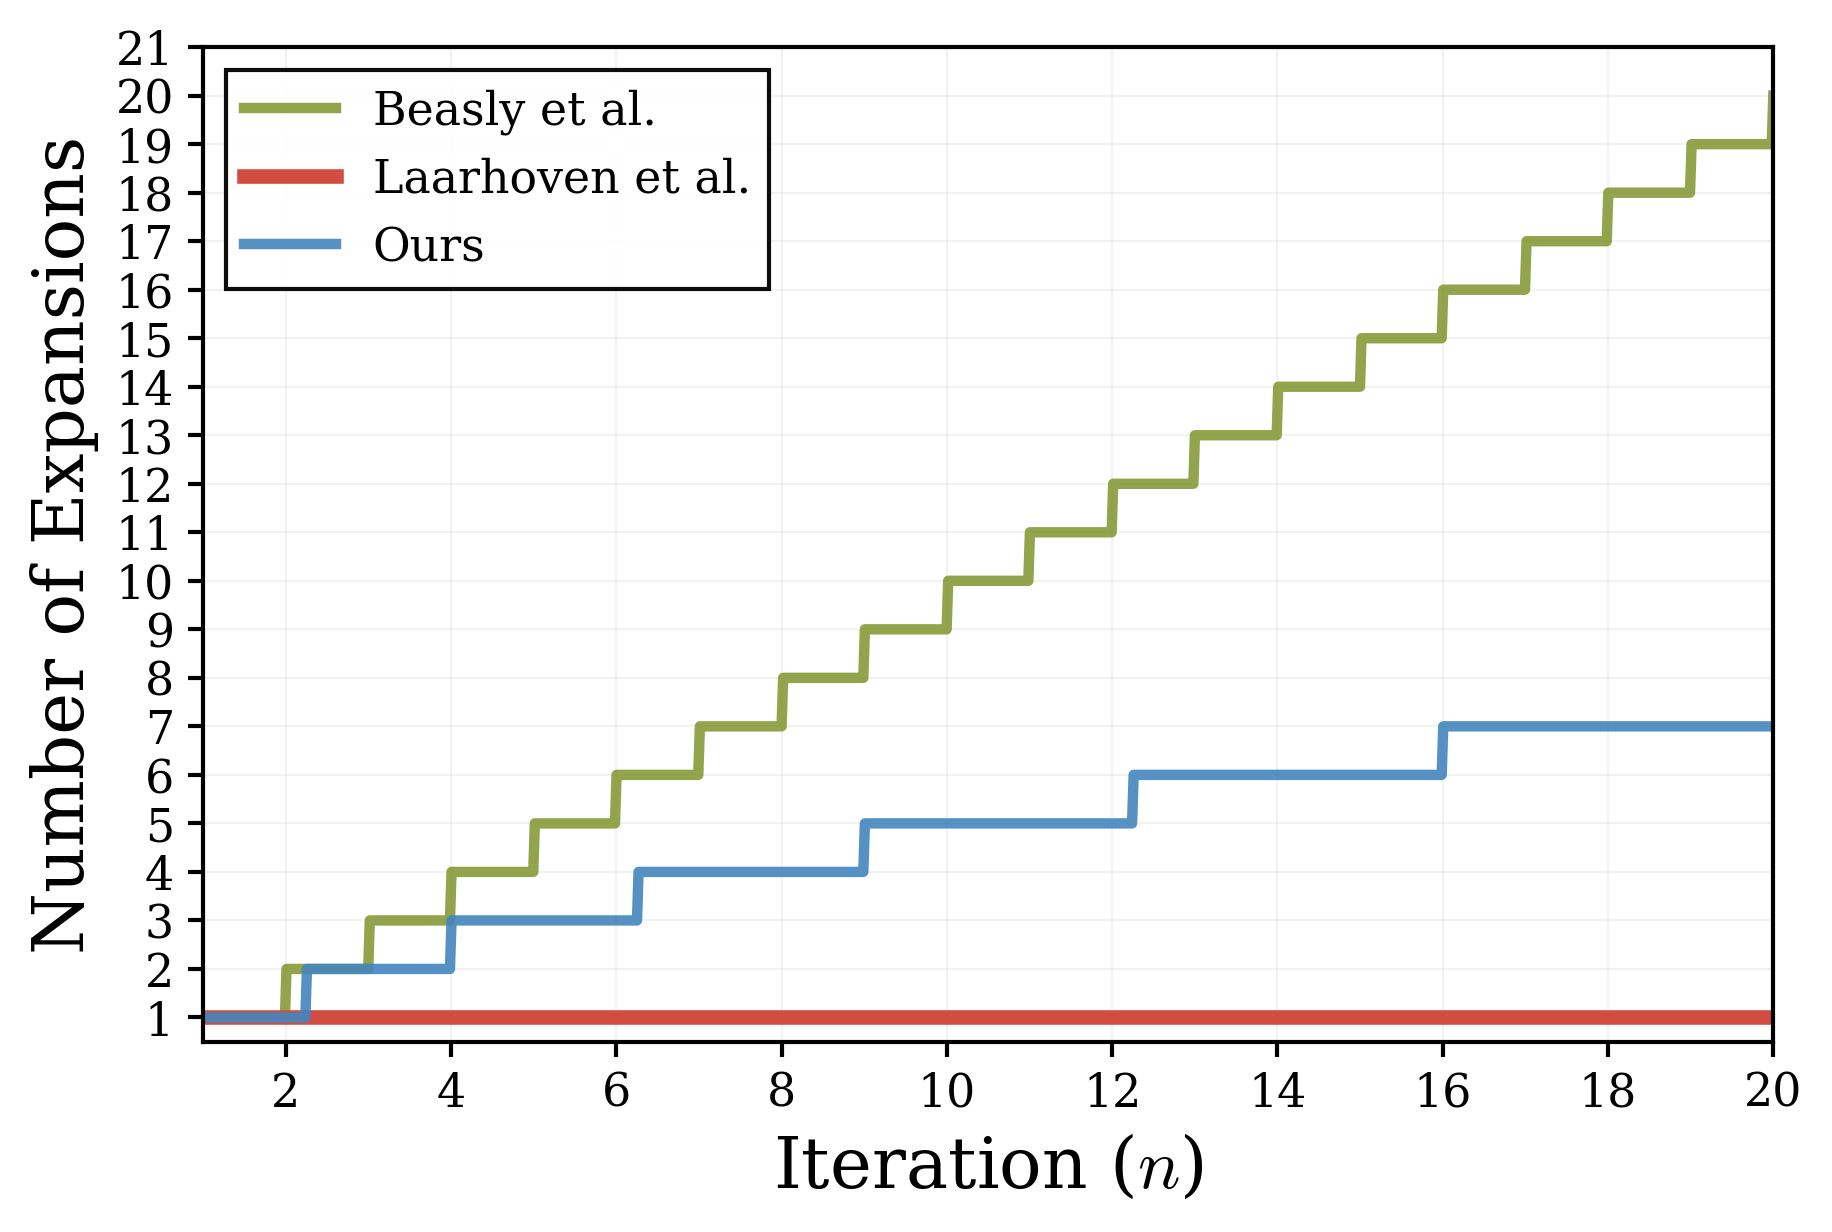

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'text.usetex': False,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
})

# Define the functions
def f(n):
    return np.floor(2 * np.sqrt(n) - 1)

def identity(n):
    return np.floor(n)

def constant_one(n):
    return np.ones_like(n)

# Create x values
n = np.linspace(1, 20, 1000)

# Calculate y values
y_step = f(n)
y_linear = identity(n)
y_constant = constant_one(n)

# Flexoki color palette
color_ours = '#4385BE'      # Blue
color_beasly = '#879A39'    # Green
color_laarhoven = '#D14D41' # Red

# Create the plot with publication-quality dimensions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Plot the functions with thick lines
ax.plot(n, y_linear, linewidth=2.5, color=color_beasly, label='Beasly et al.', alpha=0.9)
ax.plot(n, y_constant, linewidth=3.5, color=color_laarhoven, label='Laarhoven et al.', alpha=1.0, linestyle='-', dash_capstyle='round')
ax.plot(n, y_step, linewidth=2.5, color=color_ours, label='Ours', alpha=0.9)

# Add grid with subtle styling
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Labels
ax.set_xlabel(r'Iteration ($n$)', fontsize=17)
ax.set_ylabel(r'Number of Expansions', fontsize=17)

# Legend with publication styling
ax.legend(fontsize=11, loc='upper left', frameon=True, 
          fancybox=False, edgecolor='black', framealpha=0.95)

# Set axis limits
ax.set_xlim(1, 20)
ax.set_ylim(0.5, max(y_linear) + 1)

# Force integer ticks on both axes
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Set y-ticks to start at 1
y_max = int(max(y_linear) + 1)
ax.set_yticks(range(1, y_max + 1))

plt.tight_layout(pad=0.3)
plt.savefig(FIG_PATH/'expansion_curve.pdf', dpi=300, bbox_inches='tight', 
            format='pdf', backend='pdf')

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


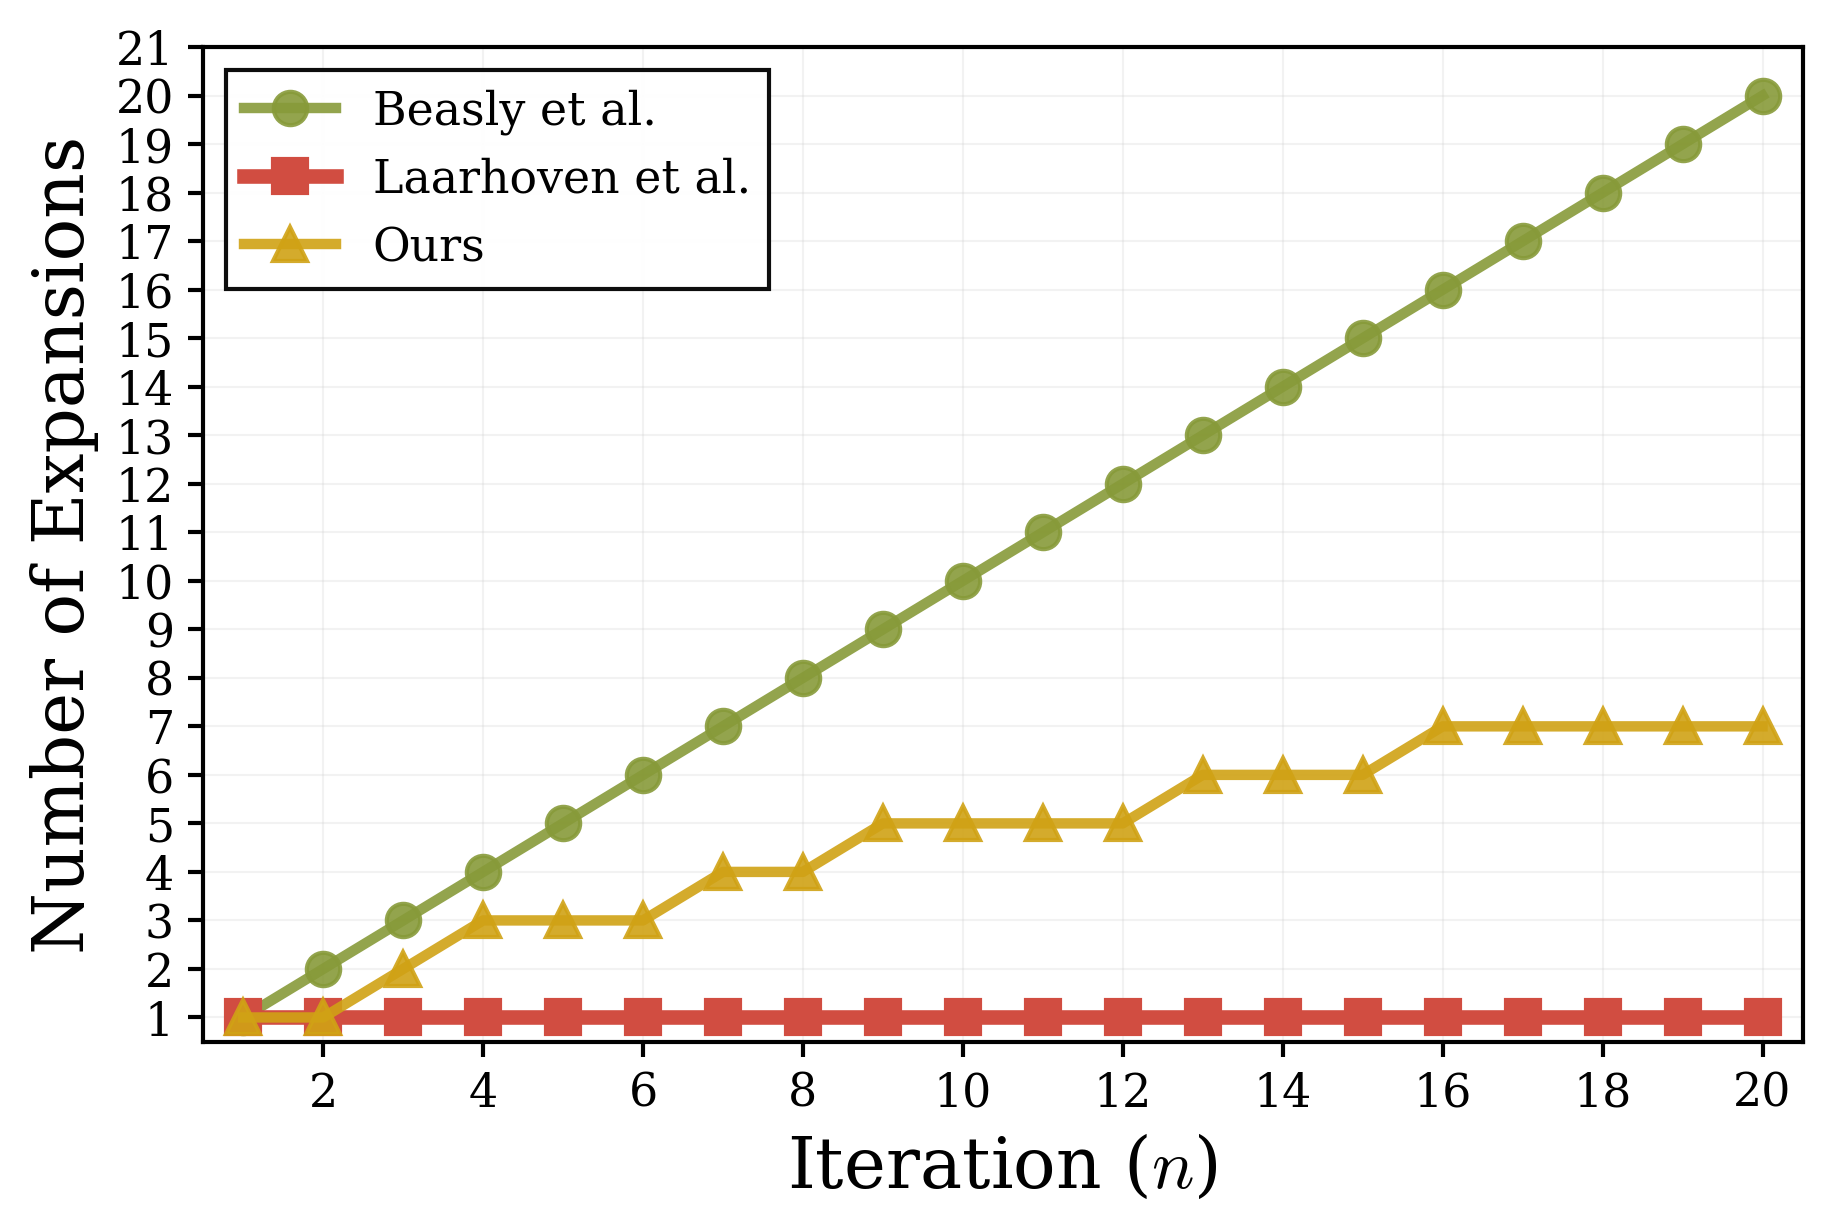

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'text.usetex': False,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
})

# Define the functions
def f(n):
    return np.floor(2 * np.sqrt(n) - 1)

def identity(n):
    return np.floor(n)

def constant_one(n):
    return np.ones_like(n)

# Create x values - INTEGER VALUES ONLY
n = np.arange(1, 21)  # This gives [1, 2, 3, ..., 20]

# Calculate y values
y_step = f(n)
y_linear = identity(n)
y_constant = constant_one(n)

# Flexoki color palette
color_ours = '#D0A215'      # Blue
color_beasly = '#879A39'    # Green
color_laarhoven = '#D14D41' # Red

# Create the plot with publication-quality dimensions
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Plot the functions with markers for discrete points
ax.plot(n, y_linear, linewidth=2.5, color=color_beasly, label='Beasly et al.', 
        alpha=0.9, marker='o', markersize=8)
ax.plot(n, y_constant, linewidth=3.5, color=color_laarhoven, label='Laarhoven et al.', 
        alpha=1.0, linestyle='-', dash_capstyle='round', marker='s', markersize=8)
ax.plot(n, y_step, linewidth=2.5, color=color_ours, label='Ours', 
        alpha=0.9, marker='^', markersize=8)

# Add grid with subtle styling
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Labels
ax.set_xlabel(r'Iteration ($n$)', fontsize=17)
ax.set_ylabel(r'Number of Expansions', fontsize=17)

# Legend with publication styling
ax.legend(fontsize=11, loc='upper left', frameon=True, 
          fancybox=False, edgecolor='black', framealpha=0.95)

# Set axis limits
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0.5, max(y_linear) + 1)

# Force integer ticks on both axes
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Set y-ticks to start at 1
y_max = int(max(y_linear) + 1)
ax.set_yticks(range(1, y_max + 1))

plt.tight_layout(pad=0.3)
plt.savefig(FIG_PATH/'expansion_curve.pdf', dpi=300, bbox_inches='tight', 
            format='pdf', backend='pdf')

plt.show()